# LIBERO Object checkpoint-20k: full-episode rollout diagnosis

This notebook compares one checkpoint rollout against the matching LIBERO
demonstration over the **entire episode**, starting both simulators from the
exact same recorded MuJoCo state.

It answers three separate questions:

1. **Command error:** how do the executed 7D policy commands differ from the
   demonstration commands at each wall-clock timestep?
2. **Robot-state error:** after applying those commands, how far is the live
   11D robot state from the demonstration replay state (EEF xyz, absolute
   rotation, and two finger positions)?
3. **Whole-simulator divergence:** how far do the raw MuJoCo states diverge?

A crucial interpretation detail: after the two trajectories diverge, the GT
action at timestep `t` was chosen for the GT state, not for the policy's state.
Thus late direct action error is descriptive, while state divergence is the
primary closed-loop result. The earlier teacher-forced notebook remains the
correct causal test of action prediction from the same observation.

The paired percent-format source is retained so this analysis is reviewable
and can also be run as a script.

In [1]:
from __future__ import annotations

import csv
import json
import math
import os
import subprocess
import sys
from pathlib import Path
from typing import Any

os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/thinkflow-cache")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/thinkflow-matplotlib")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import cv2
import h5py
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Video, display


def find_repo_root() -> Path:
    candidates: list[Path] = []
    if "__file__" in globals():
        candidates.append(Path(__file__).resolve().parents[1])
    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    for candidate in candidates:
        if (candidate / "pyproject.toml").is_file() and (
            candidate / "src/thinkflow_rdt"
        ).is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside ThinkFlow-RDT-1B")


REPO_ROOT = find_repo_root()
for import_root in (REPO_ROOT / "src", REPO_ROOT / "scripts"):
    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))

from inspect_libero_outputs import install_robosuite_mujoco_compatibility  # noqa: E402
from thinkflow_rdt.adapters.libero import (  # noqa: E402
    libero_observation_to_rdt,
    ortho6d_to_rotation_matrix,
)

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## Configuration

The default is task 0 / `demo_0`, a deterministic failed-case probe. Change
`TASK_ID` or `DEMO_NAME` and rerun all cells to inspect another episode. The
policy executes 10 commands before replanning, matching the checkpoint's
horizon-10 evaluation setting.

In [14]:
CHECKPOINT = REPO_ROOT / "output_2/libero_b0_from_oxe20k_v2/checkpoint-20000"
CONFIG_PATH = REPO_ROOT / "configs/libero_b0_native128_full.yaml"
CACHE_ROOT = REPO_ROOT / "cache_features_libero_b0_raw_ortho6d/libero_object"
DEMO_ROOT = REPO_ROOT / "libero-dataset/libero_object"
LIBERO_ROOT = Path(os.environ.get("LIBERO_ROOT", "/home/ubuntu/LIBERO"))

TASK_ID = 0
DEMO_NAME = "demo_0"
ACTION_CHUNK = 30
SEED = 42
VIDEO_RESOLUTION = 512
VIDEO_FPS = 20

QWEN_MODEL_ID = (REPO_ROOT / "model/model/stage1_unsloth").resolve()
SIGLIP_MODEL_ID = Path("/home/ubuntu/models/siglip-so400m-patch14-384")

OUTPUT_DIR = (
    CHECKPOINT.parent
    / "analysis_checkpoint-20000_libero_object_full_episode"
    / f"task_{TASK_ID:02d}_{DEMO_NAME}"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The GT replay is independent of policy settings and may be reused. Policy
# rollout artifacts are always regenerated when their cell is executed.
FORCE_GT_REPLAY = False

assert CHECKPOINT.is_dir(), CHECKPOINT
assert CONFIG_PATH.is_file(), CONFIG_PATH
assert DEMO_ROOT.is_dir(), DEMO_ROOT
assert LIBERO_ROOT.is_dir(), LIBERO_ROOT
assert QWEN_MODEL_ID.is_dir(), QWEN_MODEL_ID

## Resolve the benchmark task and exact demonstration

In [15]:
def resolve_task() -> tuple[Any, Any, Path]:
    if str(LIBERO_ROOT) not in sys.path:
        sys.path.insert(0, str(LIBERO_ROOT))
    install_robosuite_mujoco_compatibility()
    from libero.libero.benchmark import get_benchmark

    benchmark = get_benchmark("libero_object")(0)
    task = benchmark.get_task(TASK_ID)
    normalized = task.name.lower().replace(" ", "_")
    candidates = sorted(DEMO_ROOT.rglob(f"*{normalized}*_demo.hdf5"))
    if not candidates:
        candidates = sorted(DEMO_ROOT.rglob(f"*{normalized}*.hdf5"))
    if not candidates:
        raise FileNotFoundError(f"No demo HDF5 found for task {task.name!r}")
    return benchmark, task, candidates[0]


BENCHMARK, TASK, DEMO_HDF5 = resolve_task()
with h5py.File(DEMO_HDF5, "r") as handle:
    demo = handle["data"][DEMO_NAME]
    DEMO_LENGTH = int(demo["actions"].shape[0])

print(f"Task       : {TASK_ID} — {TASK.name}")
print(f"Instruction: {TASK.language}")
print(f"Demo       : {DEMO_HDF5.name}/{DEMO_NAME}")
print(f"Timesteps  : {DEMO_LENGTH}")
print(f"Output     : {OUTPUT_DIR}")

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Task       : 0 — pick_up_the_alphabet_soup_and_place_it_in_the_basket
Instruction: pick up the alphabet soup and place it in the basket
Demo       : pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo.hdf5/demo_0
Timesteps  : 148
Output     : /home/ubuntu/ThinkFlow-RDT-1B/output_2/libero_b0_from_oxe20k_v2/analysis_checkpoint-20000_libero_object_full_episode/task_00_demo_0


## Replay every demonstration action

This reference rollout deliberately does **not** stop when success is first
detected; all recorded actions are applied so there is a reference state for
every demonstration timestep.

In [16]:
GT_NPZ = OUTPUT_DIR / "ground_truth_full_episode.npz"
GT_VIDEO = OUTPUT_DIR / "ground_truth_full_episode.mp4"
GT_SUMMARY = OUTPUT_DIR / "ground_truth_full_episode.json"


def json_default(value: Any) -> Any:
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    return str(value)


def annotated_render(frame: np.ndarray, label: str) -> np.ndarray:
    # Raw MuJoCo renders use OpenGL's bottom-up convention.
    result = np.asarray(frame)[::-1].copy()
    cv2.rectangle(result, (0, 0), (result.shape[1], 36), (0, 0, 0), -1)
    cv2.putText(
        result,
        label,
        (8, 24),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.52,
        (255, 255, 255),
        1,
        cv2.LINE_AA,
    )
    return result


def run_ground_truth_replay() -> None:
    from libero.libero.envs import OffScreenRenderEnv

    with h5py.File(DEMO_HDF5, "r") as handle:
        demo = handle["data"][DEMO_NAME]
        initial_sim_state = np.asarray(demo["states"][0], dtype=np.float64)
        actions = np.asarray(demo["actions"], dtype=np.float32)[:, :7]

    env = OffScreenRenderEnv(
        bddl_file_name=BENCHMARK.get_task_bddl_file_path(TASK_ID),
        camera_heights=128,
        camera_widths=128,
        horizon=len(actions) + 10,
    )
    observation = env.reset()
    observation = env.set_init_state(initial_sim_state)
    converted = libero_observation_to_rdt(observation)

    states = [converted["state"].copy()]
    sim_states = [np.asarray(env.get_sim_state()).copy()]
    agent_frames = [np.asarray(converted["primary"]).copy()]
    wrist_frames = (
        []
        if converted["wrist"] is None
        else [np.asarray(converted["wrist"]).copy()]
    )
    rewards: list[float] = []
    success_flags: list[bool] = []

    writer = imageio.get_writer(
        GT_VIDEO,
        format="FFMPEG",
        fps=VIDEO_FPS,
        codec="libx264",
        quality=8,
    )
    try:
        for step, action in enumerate(actions):
            observation, reward, done, _ = env.step(action)
            converted = libero_observation_to_rdt(observation)
            success = bool(done) or bool(env.check_success())
            states.append(converted["state"].copy())
            sim_states.append(np.asarray(env.get_sim_state()).copy())
            agent_frames.append(np.asarray(converted["primary"]).copy())
            if converted["wrist"] is not None:
                wrist_frames.append(np.asarray(converted["wrist"]).copy())
            rewards.append(float(reward))
            success_flags.append(success)
            frame = env.env.sim.render(
                width=VIDEO_RESOLUTION,
                height=VIDEO_RESOLUTION,
                camera_name="agentview",
            )
            writer.append_data(
                annotated_render(
                    frame,
                    f"GT step={step + 1}/{len(actions)} success={int(success)}",
                )
            )
    finally:
        writer.close()
        env.close()

    np.savez_compressed(
        GT_NPZ,
        actions=actions,
        states=np.stack(states),
        sim_states=np.stack(sim_states),
        agent_frames=np.stack(agent_frames),
        wrist_frames=(
            np.stack(wrist_frames)
            if wrist_frames
            else np.empty((0, 0, 0, 3), dtype=np.uint8)
        ),
        rewards=np.asarray(rewards, dtype=np.float32),
        success=np.asarray(success_flags, dtype=bool),
    )
    first_success = np.flatnonzero(success_flags)
    summary = {
        "task_id": TASK_ID,
        "task_name": TASK.name,
        "instruction": TASK.language,
        "demo_hdf5": DEMO_HDF5.resolve(),
        "demo_name": DEMO_NAME,
        "steps": len(actions),
        "ever_success": bool(np.any(success_flags)),
        "first_success_step": (
            int(first_success[0] + 1) if first_success.size else None
        ),
        "npz": GT_NPZ.resolve(),
        "video": GT_VIDEO.resolve(),
    }
    GT_SUMMARY.write_text(
        json.dumps(summary, indent=2, default=json_default) + "\n",
        encoding="utf-8",
    )


if FORCE_GT_REPLAY or not (GT_NPZ.is_file() and GT_VIDEO.is_file()):
    run_ground_truth_replay()
else:
    print("Reusing", GT_NPZ)

display(Video(str(GT_VIDEO), embed=False, width=600))

Reusing /home/ubuntu/ThinkFlow-RDT-1B/output_2/libero_b0_from_oxe20k_v2/analysis_checkpoint-20000_libero_object_full_episode/task_00_demo_0/ground_truth_full_episode.npz


## Run checkpoint-20k from the identical simulator state

The model rollout runs in a child Python process. This prevents T5, Qwen,
SigLIP, RDT, and MuJoCo from leaving large allocations in the notebook kernel.
The debug artifacts contain every action actually sent to LIBERO and every
observed state after execution. For this checkpoint, the rollout packs the
live 11D state into native RDT slots `[10, 11, 30:39]`, samples 128D actions,
then extracts action slots `[10, 30:39]` as the trained 10D LIBERO command.

In [17]:
POLICY_RUN_LABEL = f"checkpoint20000_chunk{ACTION_CHUNK}_seed{SEED}"
POLICY_OUTPUT_DIR = OUTPUT_DIR / POLICY_RUN_LABEL
POLICY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PRED_VIDEO = POLICY_OUTPUT_DIR / "full_episode.mp4"
PRED_ACTIONS_JSONL = POLICY_OUTPUT_DIR / "actions.jsonl"
PRED_OBSERVATIONS_NPZ = POLICY_OUTPUT_DIR / "observations.npz"
PRED_SUMMARY = PRED_VIDEO.with_suffix(".json")
PRED_LOG = POLICY_OUTPUT_DIR / "rollout.log"


def local_or_fallback(local_path: Path, fallback: str) -> str:
    return str(local_path.resolve()) if local_path.exists() else fallback


def run_policy_rollout() -> None:
    command = [
        sys.executable,
        str(REPO_ROOT / "scripts/rollout_libero_rdt.py"),
        "--benchmark",
        "libero_object",
        "--task-id",
        str(TASK_ID),
        "--demo-hdf5",
        str(DEMO_HDF5.resolve()),
        "--demo-name",
        DEMO_NAME,
        "--checkpoint",
        str(CHECKPOINT.resolve()),
        "--config",
        str(CONFIG_PATH.resolve()),
        "--cache-root",
        str(CACHE_ROOT.resolve()),
        "--libero-root",
        str(LIBERO_ROOT.resolve()),
        "--action-output-mode",
        "raw_delta_ortho6d",
        "--action-chunk",
        str(ACTION_CHUNK),
        "--max-steps",
        str(DEMO_LENGTH),
        "--seed",
        str(SEED),
        "--video-resolution",
        str(VIDEO_RESOLUTION),
        "--fps",
        str(VIDEO_FPS),
        "--qwen-max-new-tokens",
        "128",
        "--qwen-model-id",
        str(QWEN_MODEL_ID),
        "--qwen-processor-id",
        str(QWEN_MODEL_ID),
        "--siglip-model-id",
        local_or_fallback(
            SIGLIP_MODEL_ID, "google/siglip-so400m-patch14-384"
        ),
        "--t5-precision",
        "bf16",
        "--output",
        str(PRED_VIDEO),
        "--action-debug-jsonl",
        str(PRED_ACTIONS_JSONL),
        "--observation-debug-npz",
        str(PRED_OBSERVATIONS_NPZ),
    ]
    print("Running:\n", " \\\n+  ".join(command))
    environment = os.environ.copy()
    environment.setdefault("MUJOCO_GL", "egl")
    with PRED_LOG.open("w", encoding="utf-8") as log_handle:
        completed = subprocess.run(
            command,
            cwd=REPO_ROOT,
            env=environment,
            stdout=log_handle,
            stderr=subprocess.STDOUT,
            check=False,
        )
    if completed.returncode != 0:
        tail = PRED_LOG.read_text(encoding="utf-8", errors="replace").splitlines()[-80:]
        raise RuntimeError(
            f"Policy rollout failed with exit code {completed.returncode}.\n"
            + "\n".join(tail)
        )
    print(PRED_LOG.read_text(encoding="utf-8", errors="replace")[-4000:])


# Intentionally run every time this cell is executed. This makes changing
# ACTION_CHUNK (or any other inference option) unambiguous and avoids silently
# analyzing stale predictions.
run_policy_rollout()

display(Video(str(PRED_VIDEO), embed=False, width=600))

Running:
 /home/ubuntu/ThinkFlow-RDT-1B/.venv/bin/python \
+  /home/ubuntu/ThinkFlow-RDT-1B/scripts/rollout_libero_rdt.py \
+  --benchmark \
+  libero_object \
+  --task-id \
+  0 \
+  --demo-hdf5 \
+  /home/ubuntu/ThinkFlow-RDT-1B/libero-dataset/libero_object/pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo.hdf5 \
+  --demo-name \
+  demo_0 \
+  --checkpoint \
+  /home/ubuntu/ThinkFlow-RDT-1B/output_2/libero_b0_from_oxe20k_v2/checkpoint-20000 \
+  --config \
+  /home/ubuntu/ThinkFlow-RDT-1B/configs/libero_b0_native128_full.yaml \
+  --cache-root \
+  /home/ubuntu/ThinkFlow-RDT-1B/cache_features_libero_b0_raw_ortho6d/libero_object \
+  --libero-root \
+  /home/ubuntu/LIBERO \
+  --action-output-mode \
+  raw_delta_ortho6d \
+  --action-chunk \
+  30 \
+  --max-steps \
+  148 \
+  --seed \
+  42 \
+  --video-resolution \
+  512 \
+  --fps \
+  20 \
+  --qwen-max-new-tokens \
+  128 \
+  --qwen-model-id \
+  /home/ubuntu/ThinkFlow-RDT-1B/model/model/stage1_unsloth \
+  --qwen-pr

## Load and align the two complete trajectories

`state[t + 1]` is the state observed after executing `action[t]`. The direct
comparison below uses this exact indexing; there is no one-step shift.

In [18]:
def load_jsonl(path: Path) -> list[dict[str, Any]]:
    with path.open("r", encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


def flatten_executed_actions(rows: list[dict[str, Any]]) -> np.ndarray:
    chunks = [
        np.asarray(row["executed_libero_actions"], dtype=np.float32)
        for row in rows
        if row.get("executed_libero_actions")
    ]
    if not chunks:
        raise RuntimeError("No executed actions found in action-debug JSONL")
    return np.concatenate(chunks, axis=0)


gt_archive = np.load(GT_NPZ)
pred_archive = np.load(PRED_OBSERVATIONS_NPZ)
plan_rows = load_jsonl(PRED_ACTIONS_JSONL)

gt_actions_all = np.asarray(gt_archive["actions"], dtype=np.float32)
pred_actions_all = flatten_executed_actions(plan_rows)
gt_states_all = np.asarray(gt_archive["states"], dtype=np.float32)
pred_states_all = np.asarray(pred_archive["states"], dtype=np.float32)
gt_sim_states_all = np.asarray(gt_archive["sim_states"], dtype=np.float64)
pred_sim_states_all = (
    np.asarray(pred_archive["sim_states"], dtype=np.float64)
    if "sim_states" in pred_archive.files
    else None
)

T = min(
    len(gt_actions_all),
    len(pred_actions_all),
    len(gt_states_all) - 1,
    len(pred_states_all) - 1,
)
assert T > 0

gt_actions = gt_actions_all[:T]
pred_actions = pred_actions_all[:T]
gt_before = gt_states_all[:T]
pred_before = pred_states_all[:T]
gt_after = gt_states_all[1 : T + 1]
pred_after = pred_states_all[1 : T + 1]
steps = np.arange(T)

print(f"GT actions          : {gt_actions_all.shape}")
print(f"Pred executed       : {pred_actions_all.shape}")
print(f"GT 11D states       : {gt_states_all.shape}")
print(f"Pred 11D states     : {pred_states_all.shape}")
print(f"Aligned transitions : {T}")
print(f"Policy replans      : {len(plan_rows)} (chunk={ACTION_CHUNK})")
if T < len(gt_actions_all):
    print("NOTE: policy rollout ended before the demonstration; plots stop at policy termination.")

GT actions          : (148, 7)
Pred executed       : (148, 7)
GT 11D states       : (149, 11)
Pred 11D states     : (149, 11)
Aligned transitions : 148
Policy replans      : 5 (chunk=30)


## Error definitions and numerical summary

In [19]:
RAW_ACTION_NAMES = ("dx", "dy", "dz", "droll", "dpitch", "dyaw", "gripper")
STATE_NAMES = (
    "eef_x",
    "eef_y",
    "eef_z",
    "rot6d_0",
    "rot6d_1",
    "rot6d_2",
    "rot6d_3",
    "rot6d_4",
    "rot6d_5",
    "finger_left",
    "finger_right",
)


def rotation_geodesic_degrees(a6: np.ndarray, b6: np.ndarray) -> np.ndarray:
    a = ortho6d_to_rotation_matrix(np.asarray(a6))
    b = ortho6d_to_rotation_matrix(np.asarray(b6))
    relative = np.swapaxes(a, -1, -2) @ b
    cosine = np.clip(
        (np.trace(relative, axis1=-2, axis2=-1) - 1.0) / 2.0,
        -1.0,
        1.0,
    )
    return np.degrees(np.arccos(cosine))


def safe_div(numerator: int | float, denominator: int | float) -> float:
    return float(numerator / denominator) if denominator else math.nan


def binary_metrics(predicted: np.ndarray, target: np.ndarray) -> dict[str, Any]:
    pred = np.asarray(predicted, dtype=bool)
    true = np.asarray(target, dtype=bool)
    tp = int(np.sum(pred & true))
    fp = int(np.sum(pred & ~true))
    fn = int(np.sum(~pred & true))
    tn = int(np.sum(~pred & ~true))
    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "accuracy": safe_div(tp + tn, len(true)),
        "precision": precision,
        "recall": recall,
        "f1": safe_div(2 * precision * recall, precision + recall),
    }


def transition_indices(closed: np.ndarray) -> np.ndarray:
    values = np.asarray(closed, dtype=bool)
    return np.flatnonzero(values[1:] != values[:-1]) + 1


def match_transitions(
    predicted: np.ndarray,
    target: np.ndarray,
    tolerance: int = 2,
) -> dict[str, Any]:
    pred_events = transition_indices(predicted).tolist()
    target_events = transition_indices(target).tolist()
    unmatched = set(pred_events)
    offsets: list[int] = []
    for target_step in target_events:
        candidates = [step for step in unmatched if abs(step - target_step) <= tolerance]
        if candidates:
            match = min(candidates, key=lambda step: abs(step - target_step))
            unmatched.remove(match)
            offsets.append(match - target_step)
    tp = len(offsets)
    fp = len(unmatched)
    fn = len(target_events) - tp
    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    return {
        "tolerance_steps": tolerance,
        "target_transition_steps": target_events,
        "predicted_transition_steps": pred_events,
        "matched": tp,
        "false_positive": fp,
        "false_negative": fn,
        "precision": precision,
        "recall": recall,
        "f1": safe_div(2 * precision * recall, precision + recall),
        "signed_timing_offsets": offsets,
        "mean_abs_timing_error": (
            float(np.mean(np.abs(offsets))) if offsets else math.nan
        ),
    }


action_abs_error = np.abs(pred_actions - gt_actions)
action_xyz_error = np.linalg.norm(pred_actions[:, :3] - gt_actions[:, :3], axis=1)
action_rot_command_error = np.linalg.norm(
    pred_actions[:, 3:6] - gt_actions[:, 3:6], axis=1
)
state_xyz_error_cm = 100.0 * np.linalg.norm(pred_after[:, :3] - gt_after[:, :3], axis=1)
state_rotation_error_deg = rotation_geodesic_degrees(pred_after[:, 3:9], gt_after[:, 3:9])
state_finger_mae = np.mean(np.abs(pred_after[:, 9:11] - gt_after[:, 9:11]), axis=1)

# LIBERO raw command convention in this project: positive = close/hold.
gt_closed = gt_actions[:, 6] >= 0.0
pred_closed = pred_actions[:, 6] >= 0.0
gripper_classification = binary_metrics(pred_closed, gt_closed)
gripper_transitions = match_transitions(pred_closed, gt_closed, tolerance=2)

sim_state_l2 = None
if pred_sim_states_all is not None:
    sim_T = min(T, len(gt_sim_states_all) - 1, len(pred_sim_states_all) - 1)
    sim_state_l2 = np.linalg.norm(
        pred_sim_states_all[1 : sim_T + 1] - gt_sim_states_all[1 : sim_T + 1],
        axis=1,
    )

policy_summary = json.loads(PRED_SUMMARY.read_text(encoding="utf-8"))
summary = {
    "task_id": TASK_ID,
    "task_name": TASK.name,
    "instruction": TASK.language,
    "demo_name": DEMO_NAME,
    "aligned_timesteps": T,
    "action_chunk": ACTION_CHUNK,
    "policy_success": bool(policy_summary["success"]),
    "policy_steps": int(policy_summary["steps"]),
    "mean_action_xyz_l2": float(action_xyz_error.mean()),
    "final_action_xyz_l2": float(action_xyz_error[-1]),
    "mean_action_rotation_command_l2": float(action_rot_command_error.mean()),
    "mean_state_xyz_error_cm": float(state_xyz_error_cm.mean()),
    "final_state_xyz_error_cm": float(state_xyz_error_cm[-1]),
    "mean_state_rotation_error_deg": float(state_rotation_error_deg.mean()),
    "final_state_rotation_error_deg": float(state_rotation_error_deg[-1]),
    "mean_state_finger_mae": float(state_finger_mae.mean()),
    "gripper_classification": gripper_classification,
    "gripper_transitions": gripper_transitions,
}
if sim_state_l2 is not None:
    summary["raw_sim_state_l2"] = {
        "mean": float(sim_state_l2.mean()),
        "final": float(sim_state_l2[-1]),
        "max": float(sim_state_l2.max()),
    }

SUMMARY_PATH = POLICY_OUTPUT_DIR / "full_episode_summary.json"
SUMMARY_PATH.write_text(
    json.dumps(summary, indent=2, default=json_default) + "\n",
    encoding="utf-8",
)
print(json.dumps(summary, indent=2, default=json_default))

{
  "task_id": 0,
  "task_name": "pick_up_the_alphabet_soup_and_place_it_in_the_basket",
  "instruction": "pick up the alphabet soup and place it in the basket",
  "demo_name": "demo_0",
  "aligned_timesteps": 148,
  "action_chunk": 30,
  "policy_success": false,
  "policy_steps": 148,
  "mean_action_xyz_l2": 0.7685711979866028,
  "final_action_xyz_l2": 0.6664100885391235,
  "mean_action_rotation_command_l2": 0.07395263761281967,
  "mean_state_xyz_error_cm": 25.713354110717773,
  "final_state_xyz_error_cm": 46.60818099975586,
  "mean_state_rotation_error_deg": 8.806866645812988,
  "final_state_rotation_error_deg": 10.909124374389648,
  "mean_state_finger_mae": 0.00989149883389473,
  "gripper_classification": {
    "tp": 42,
    "fp": 0,
    "fn": 44,
    "tn": 62,
    "accuracy": 0.7027027027027027,
    "precision": 1.0,
    "recall": 0.4883720930232558,
    "f1": 0.65625
  },
  "gripper_transitions": {
    "tolerance_steps": 2,
    "target_transition_steps": [
      42,
      128
    

## Ground-truth action vs executed predicted action — every timestep

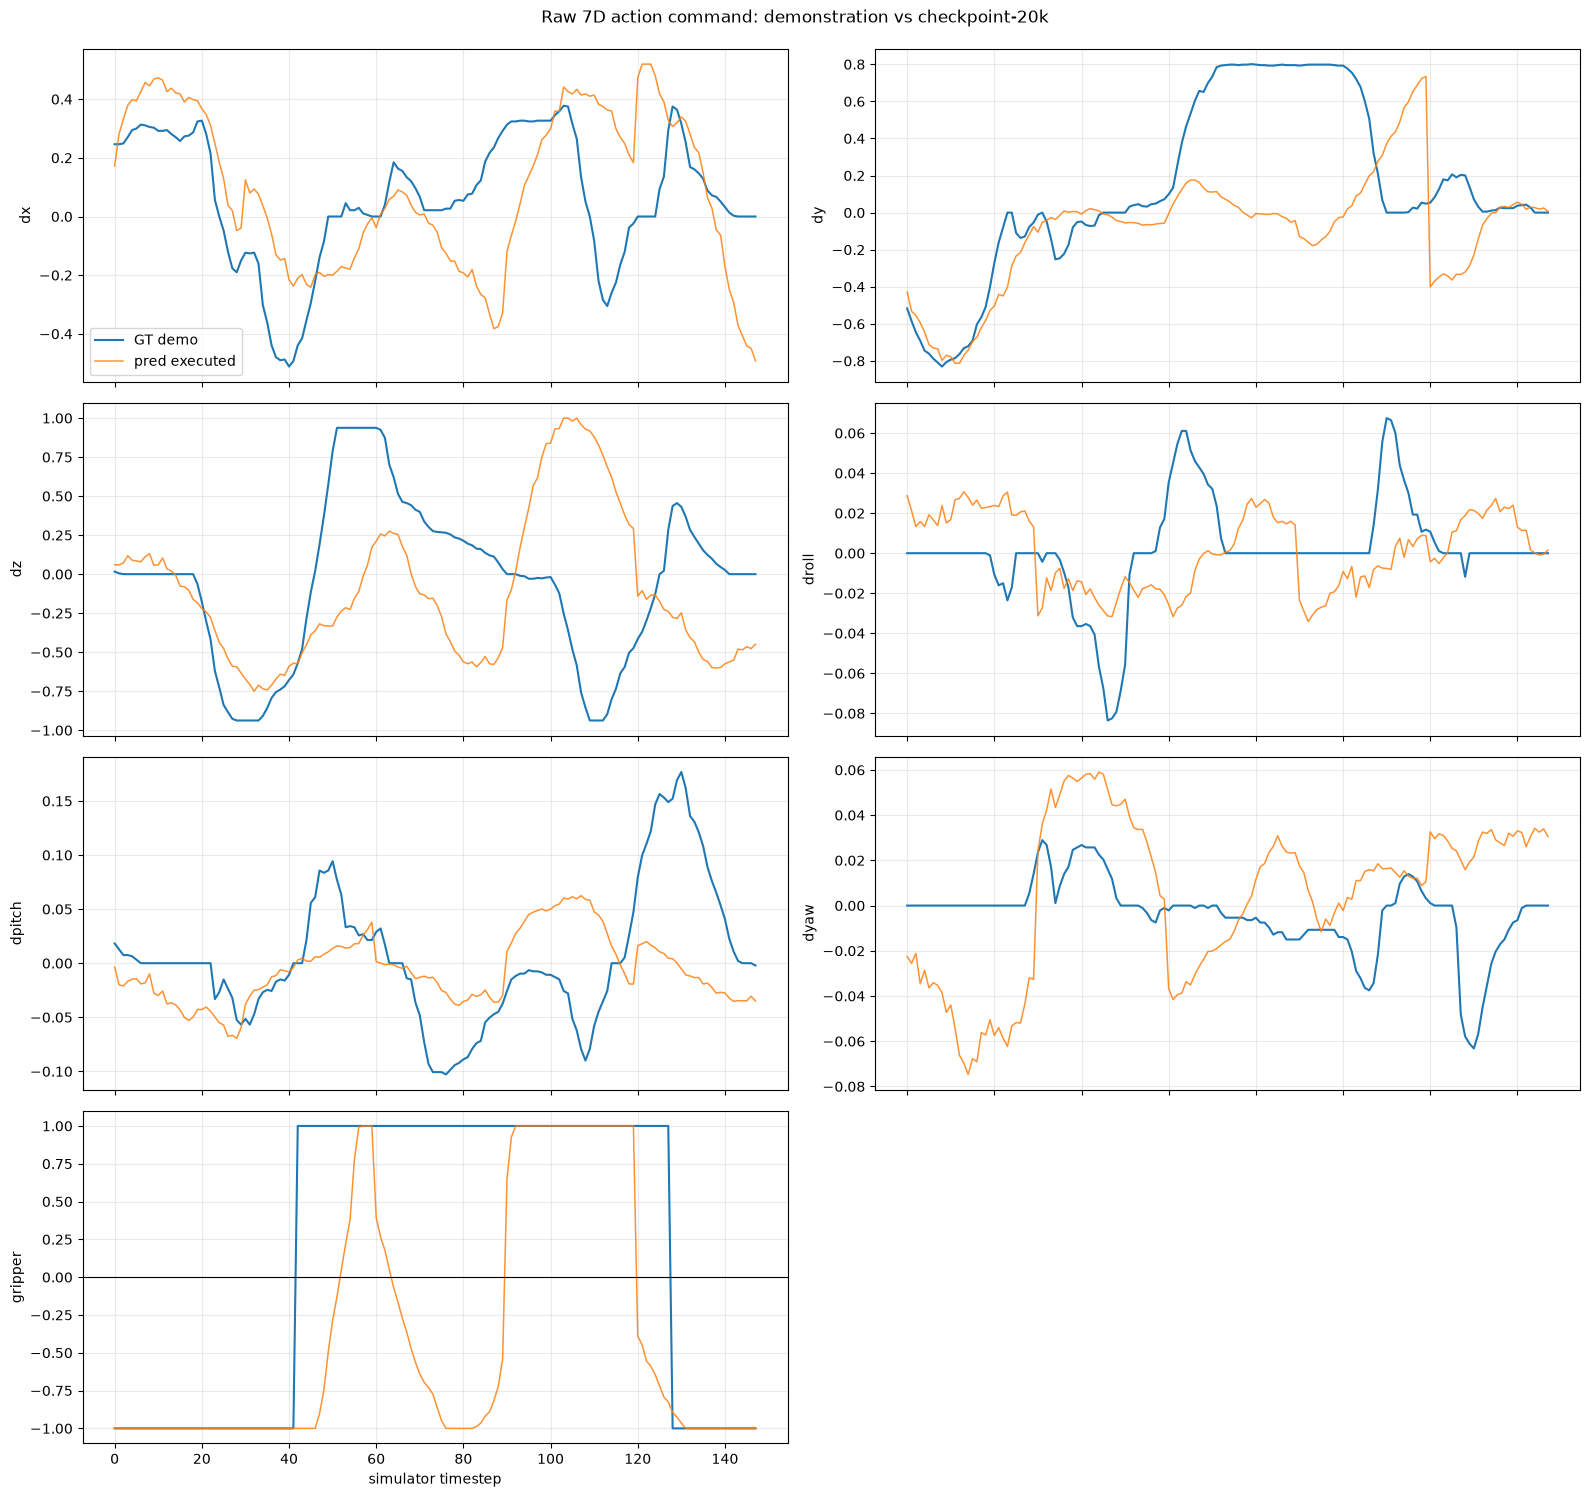

In [20]:
fig, axes = plt.subplots(4, 2, figsize=(16, 15), sharex=True)
for dimension, axis in enumerate(axes.flat[:7]):
    axis.plot(steps, gt_actions[:, dimension], label="GT demo", linewidth=1.5)
    axis.plot(steps, pred_actions[:, dimension], label="pred executed", linewidth=1.1, alpha=0.85)
    axis.set_ylabel(RAW_ACTION_NAMES[dimension])
    axis.grid(alpha=0.25)
    if dimension == 6:
        axis.axhline(0.0, color="black", linewidth=0.8)
axes.flat[0].legend(loc="best")
axes.flat[7].axis("off")
axes.flat[-2].set_xlabel("simulator timestep")
fig.suptitle("Raw 7D action command: demonstration vs checkpoint-20k", y=0.995)
fig.tight_layout()
ACTION_TRACE_PATH = POLICY_OUTPUT_DIR / "action_traces_all_timesteps.png"
fig.savefig(ACTION_TRACE_PATH, dpi=170, bbox_inches="tight")
plt.show()

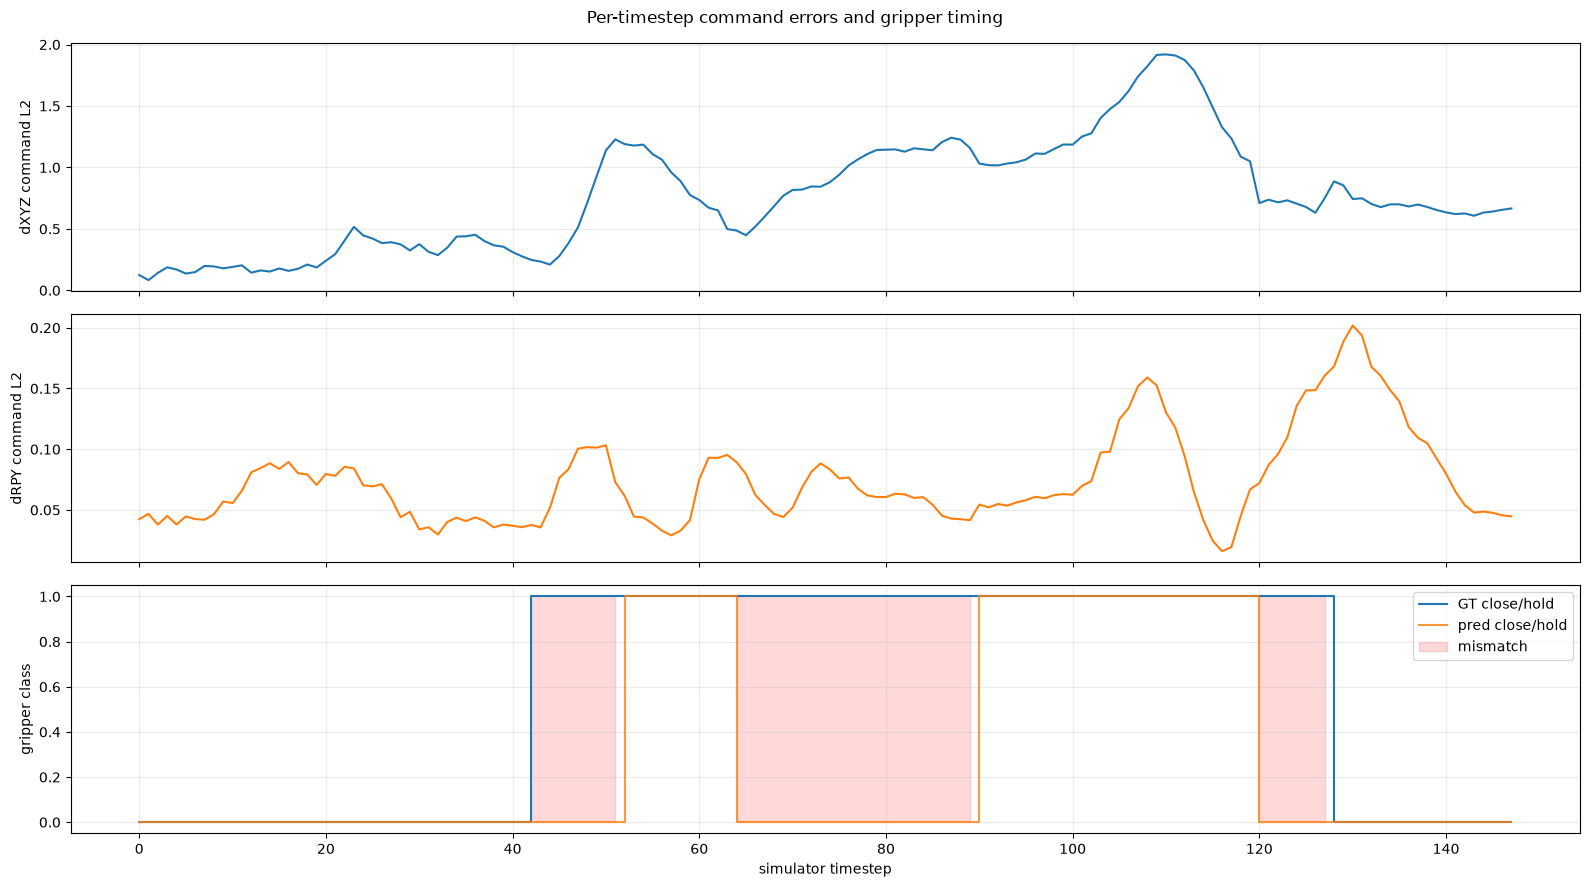

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
axes[0].plot(steps, action_xyz_error)
axes[0].set_ylabel("dXYZ command L2")
axes[1].plot(steps, action_rot_command_error, color="tab:orange")
axes[1].set_ylabel("dRPY command L2")
axes[2].step(steps, gt_closed.astype(int), where="post", label="GT close/hold")
axes[2].step(steps, pred_closed.astype(int), where="post", label="pred close/hold", alpha=0.8)
axes[2].fill_between(
    steps,
    0,
    1,
    where=pred_closed != gt_closed,
    color="red",
    alpha=0.15,
    label="mismatch",
)
axes[2].set_ylabel("gripper class")
axes[2].set_xlabel("simulator timestep")
axes[2].legend(loc="best")
for axis in axes:
    axis.grid(alpha=0.25)
fig.suptitle("Per-timestep command errors and gripper timing")
fig.tight_layout()
ACTION_ERROR_PATH = POLICY_OUTPUT_DIR / "action_errors_and_gripper_timing.png"
fig.savefig(ACTION_ERROR_PATH, dpi=170, bbox_inches="tight")
plt.show()

## GT robot state vs robot state after executing the predicted action

Each plotted point is aligned *after* its corresponding command: GT
`state[t+1]` versus predicted-rollout `state[t+1]`.

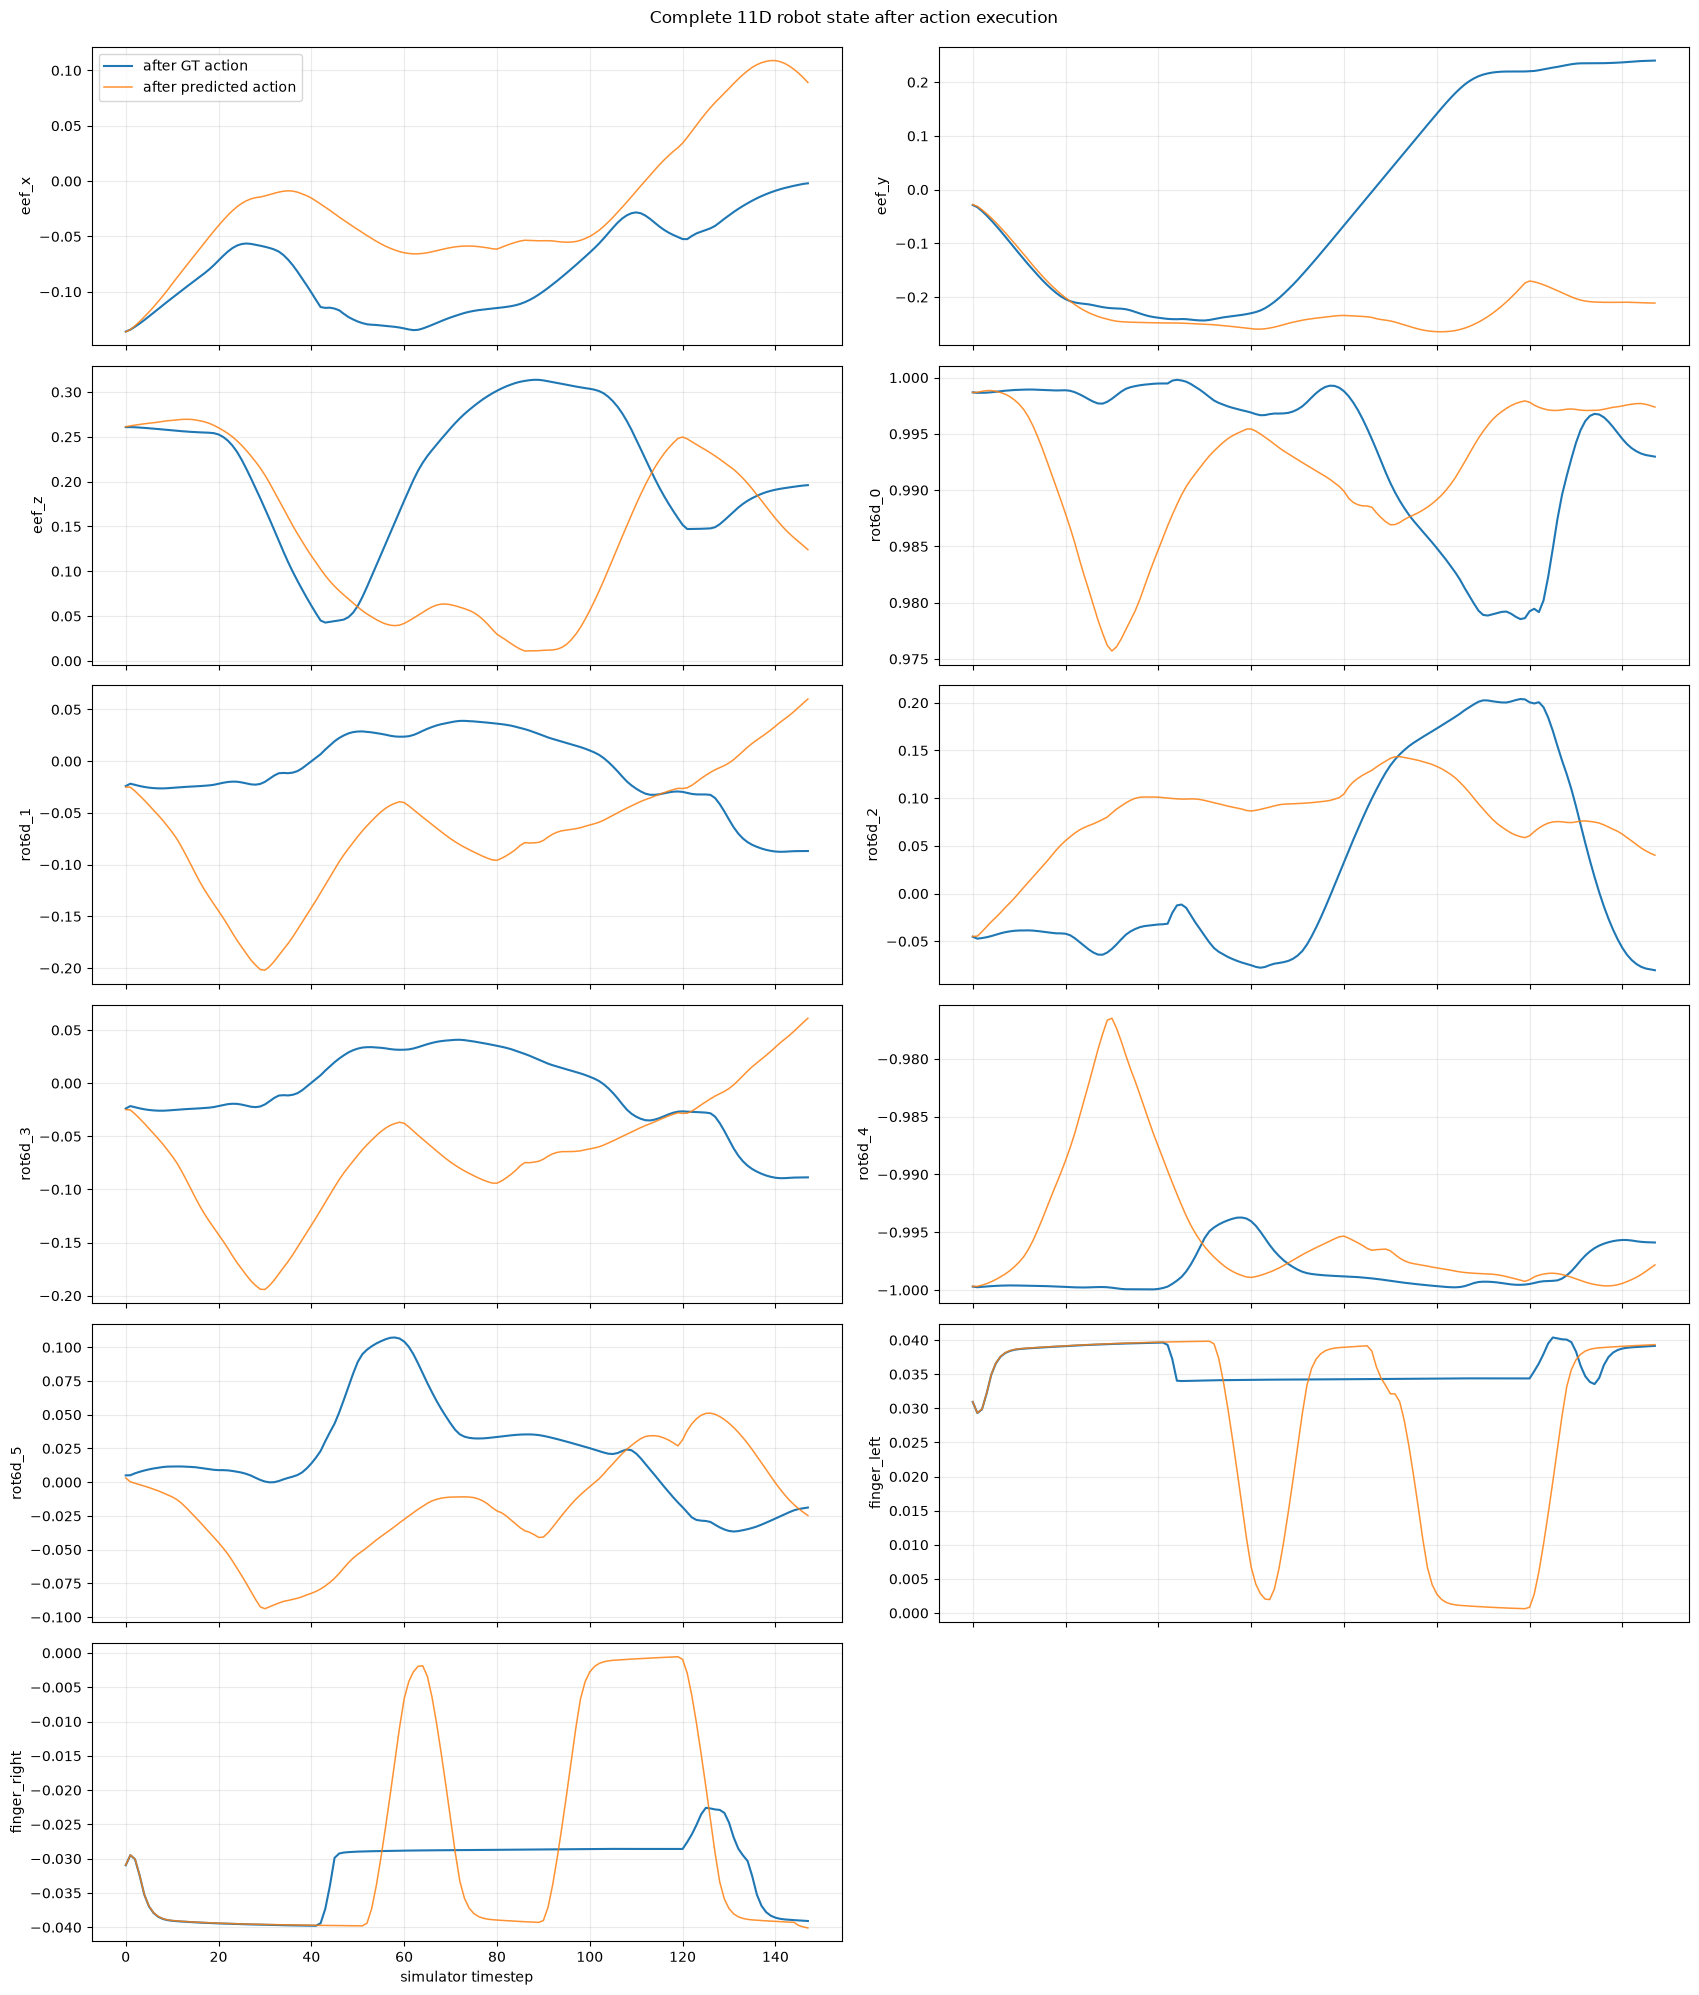

In [22]:
fig, axes = plt.subplots(6, 2, figsize=(17, 20), sharex=True)
for dimension, axis in enumerate(axes.flat[:11]):
    axis.plot(steps, gt_after[:, dimension], label="after GT action", linewidth=1.5)
    axis.plot(steps, pred_after[:, dimension], label="after predicted action", linewidth=1.1, alpha=0.85)
    axis.set_ylabel(STATE_NAMES[dimension])
    axis.grid(alpha=0.25)
axes.flat[0].legend(loc="best")
axes.flat[11].axis("off")
axes.flat[10].set_xlabel("simulator timestep")
fig.suptitle("Complete 11D robot state after action execution", y=0.995)
fig.tight_layout()
STATE_TRACE_PATH = POLICY_OUTPUT_DIR / "state_traces_after_execution_all_timesteps.png"
fig.savefig(STATE_TRACE_PATH, dpi=170, bbox_inches="tight")
plt.show()

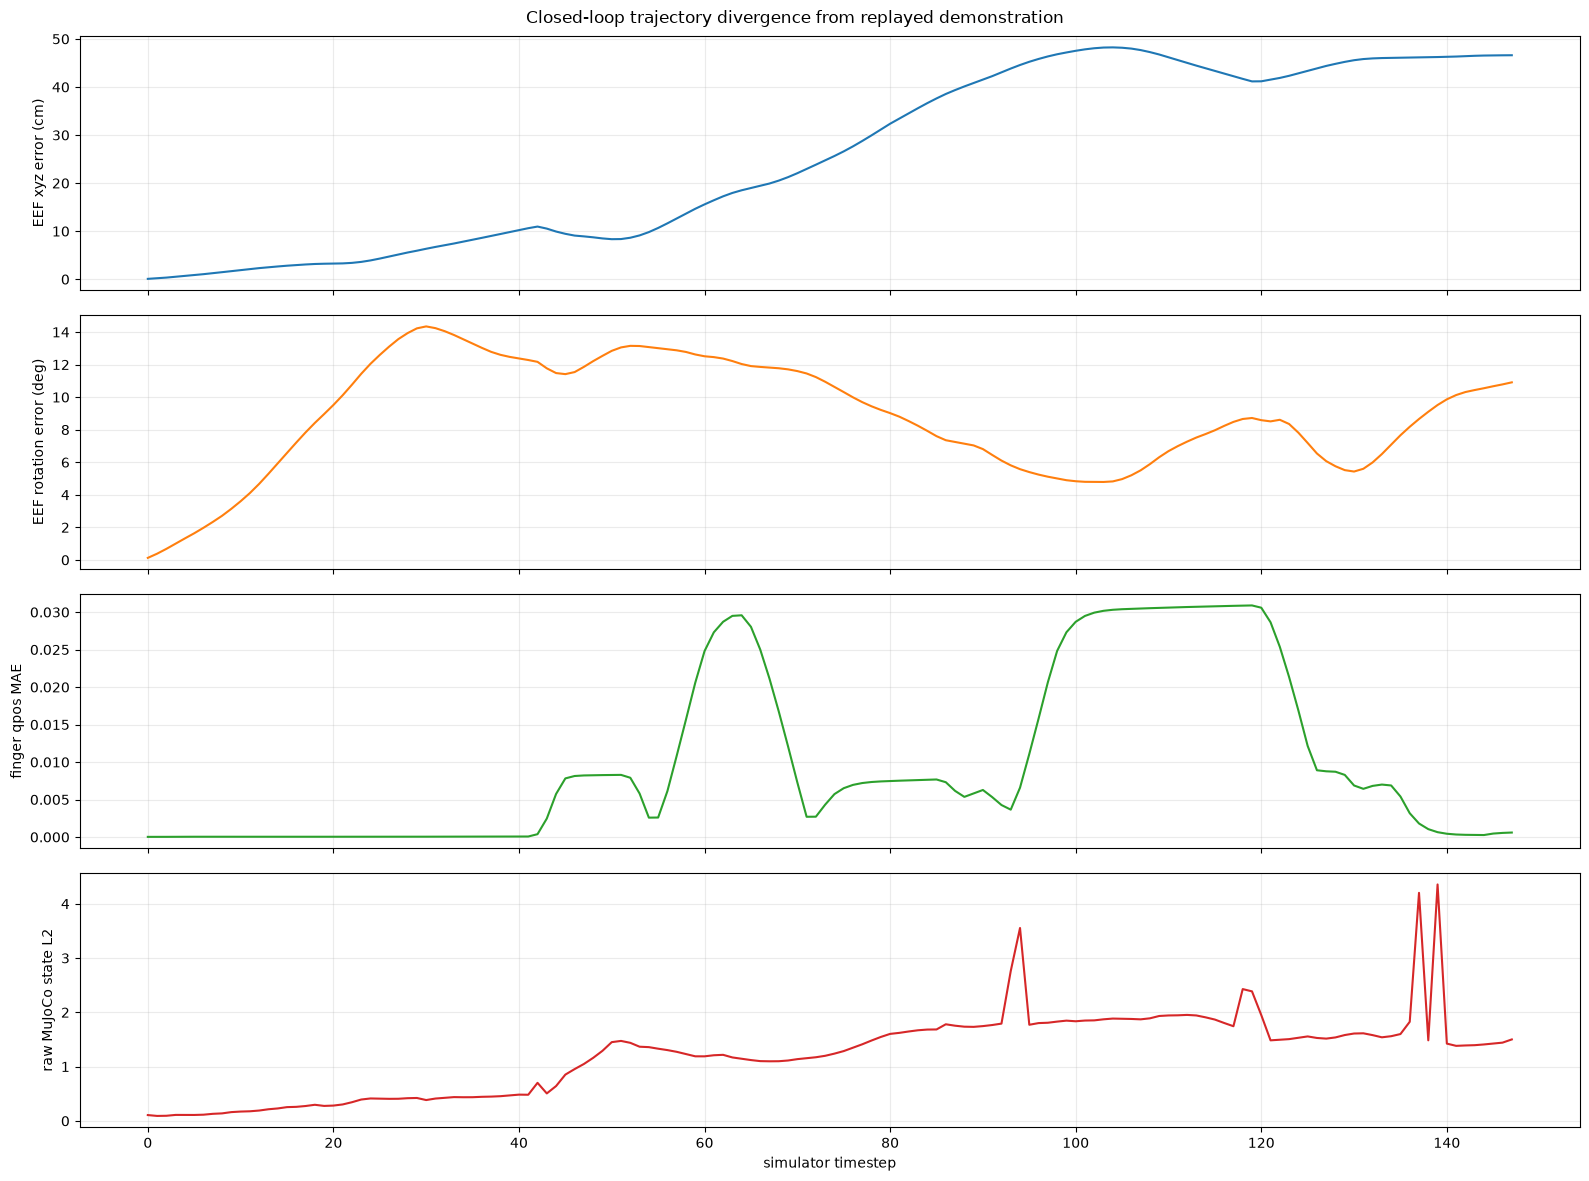

In [23]:
plot_count = 4 if sim_state_l2 is not None else 3
fig, axes = plt.subplots(plot_count, 1, figsize=(16, 3.0 * plot_count), sharex=True)
axes[0].plot(steps, state_xyz_error_cm, color="tab:blue")
axes[0].set_ylabel("EEF xyz error (cm)")
axes[1].plot(steps, state_rotation_error_deg, color="tab:orange")
axes[1].set_ylabel("EEF rotation error (deg)")
axes[2].plot(steps, state_finger_mae, color="tab:green")
axes[2].set_ylabel("finger qpos MAE")
if sim_state_l2 is not None:
    axes[3].plot(np.arange(len(sim_state_l2)), sim_state_l2, color="tab:red")
    axes[3].set_ylabel("raw MuJoCo state L2")
axes[-1].set_xlabel("simulator timestep")
for axis in axes:
    axis.grid(alpha=0.25)
fig.suptitle("Closed-loop trajectory divergence from replayed demonstration")
fig.tight_layout()
STATE_ERROR_PATH = POLICY_OUTPUT_DIR / "state_divergence_all_timesteps.png"
fig.savefig(STATE_ERROR_PATH, dpi=170, bbox_inches="tight")
plt.show()

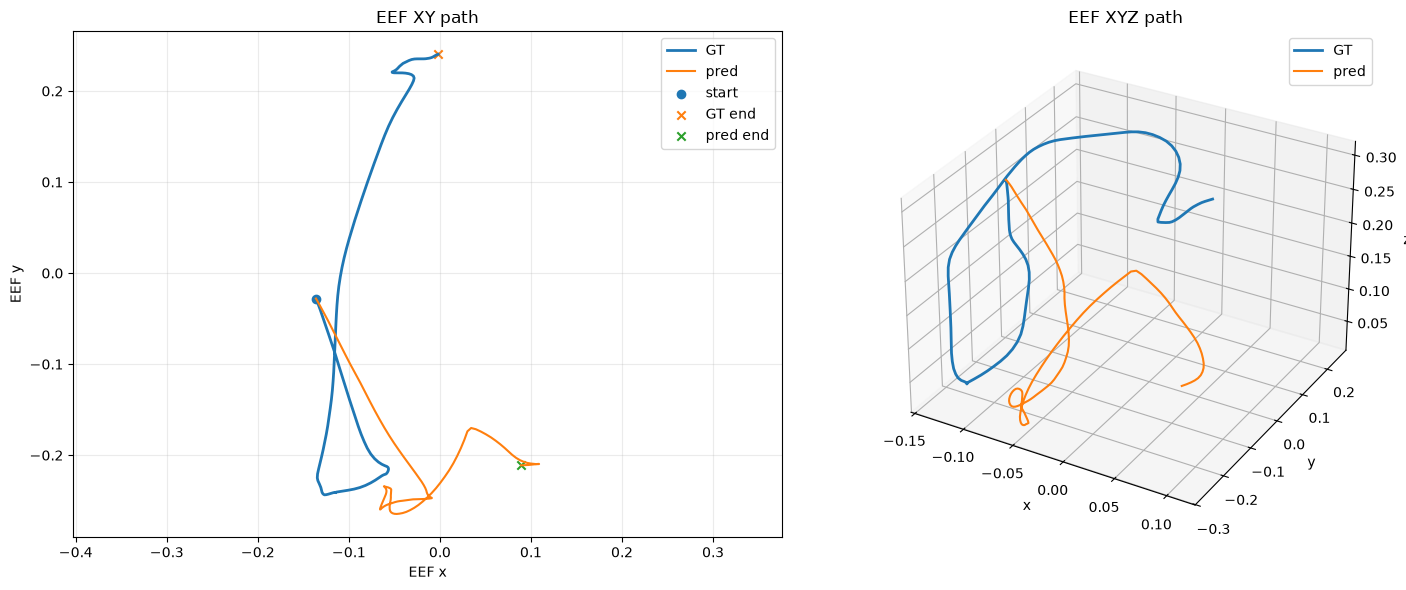

In [24]:
fig = plt.figure(figsize=(15, 6))
ax_xy = fig.add_subplot(1, 2, 1)
ax_xy.plot(gt_after[:, 0], gt_after[:, 1], label="GT", linewidth=2)
ax_xy.plot(pred_after[:, 0], pred_after[:, 1], label="pred", linewidth=1.5)
ax_xy.scatter(gt_after[0, 0], gt_after[0, 1], marker="o", label="start")
ax_xy.scatter(gt_after[-1, 0], gt_after[-1, 1], marker="x", label="GT end")
ax_xy.scatter(pred_after[-1, 0], pred_after[-1, 1], marker="x", label="pred end")
ax_xy.set_xlabel("EEF x")
ax_xy.set_ylabel("EEF y")
ax_xy.set_title("EEF XY path")
ax_xy.axis("equal")
ax_xy.grid(alpha=0.25)
ax_xy.legend()

ax_3d = fig.add_subplot(1, 2, 2, projection="3d")
ax_3d.plot(*gt_after[:, :3].T, label="GT", linewidth=2)
ax_3d.plot(*pred_after[:, :3].T, label="pred", linewidth=1.5)
ax_3d.set_xlabel("x")
ax_3d.set_ylabel("y")
ax_3d.set_zlabel("z")
ax_3d.set_title("EEF XYZ path")
ax_3d.legend()
fig.tight_layout()
EEF_PATH = POLICY_OUTPUT_DIR / "eef_paths_xy_xyz.png"
fig.savefig(EEF_PATH, dpi=170, bbox_inches="tight")
plt.show()

## Error growth by episode phase

Quartiles make it easier to see whether the model starts incorrectly or
tracks initially and accumulates error near approach/grasp/transport.

{'phase': 1, 'start_step': 0, 'end_step_exclusive': 37, 'action_xyz_l2': 0.26435500383377075, 'action_rotation_l2': 0.05892222747206688, 'gripper_accuracy': 1.0, 'state_xyz_error_cm': 3.5222280025482178, 'state_rotation_error_deg': 7.987114906311035, 'finger_mae': 3.708201620611362e-05}
{'phase': 2, 'start_step': 37, 'end_step_exclusive': 74, 'action_xyz_l2': 0.6843591928482056, 'action_rotation_l2': 0.062181368470191956, 'gripper_accuracy': 0.4594594594594595, 'state_xyz_error_cm': 13.839681625366211, 'state_rotation_error_deg': 12.240172386169434, 'finger_mae': 0.010761071927845478}
{'phase': 3, 'start_step': 74, 'end_step_exclusive': 111, 'action_xyz_l2': 1.2368133068084717, 'action_rotation_l2': 0.07536980509757996, 'gripper_accuracy': 0.5675675675675675, 'state_xyz_error_cm': 40.7945442199707, 'state_rotation_error_deg': 6.841716289520264, 'finger_mae': 0.015366770327091217}
{'phase': 4, 'start_step': 111, 'end_step_exclusive': 148, 'action_xyz_l2': 0.8887572288513184, 'action_rot

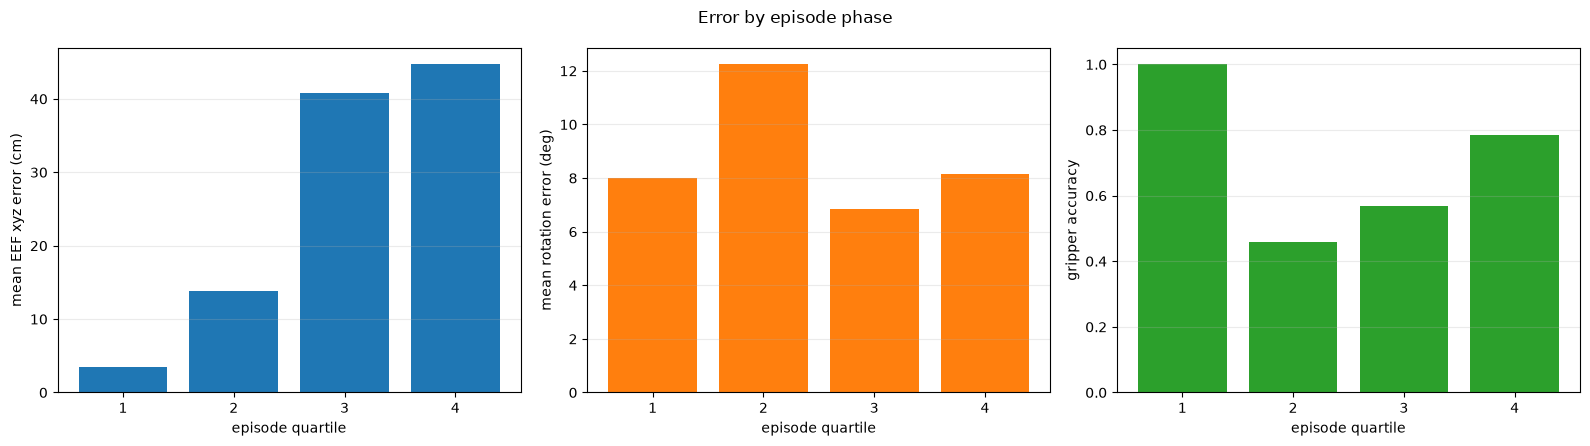

In [25]:
phase_edges = np.linspace(0, T, 5, dtype=int)
phase_rows: list[dict[str, Any]] = []
for phase in range(4):
    start, end = int(phase_edges[phase]), int(phase_edges[phase + 1])
    if end <= start:
        continue
    phase_rows.append(
        {
            "phase": phase + 1,
            "start_step": start,
            "end_step_exclusive": end,
            "action_xyz_l2": float(action_xyz_error[start:end].mean()),
            "action_rotation_l2": float(action_rot_command_error[start:end].mean()),
            "gripper_accuracy": float(np.mean(pred_closed[start:end] == gt_closed[start:end])),
            "state_xyz_error_cm": float(state_xyz_error_cm[start:end].mean()),
            "state_rotation_error_deg": float(state_rotation_error_deg[start:end].mean()),
            "finger_mae": float(state_finger_mae[start:end].mean()),
        }
    )

for row in phase_rows:
    print(row)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
phase_numbers = [row["phase"] for row in phase_rows]
axes[0].bar(phase_numbers, [row["state_xyz_error_cm"] for row in phase_rows])
axes[0].set_ylabel("mean EEF xyz error (cm)")
axes[1].bar(phase_numbers, [row["state_rotation_error_deg"] for row in phase_rows], color="tab:orange")
axes[1].set_ylabel("mean rotation error (deg)")
axes[2].bar(phase_numbers, [row["gripper_accuracy"] for row in phase_rows], color="tab:green")
axes[2].set_ylabel("gripper accuracy")
for axis in axes:
    axis.set_xlabel("episode quartile")
    axis.set_xticks(phase_numbers)
    axis.grid(axis="y", alpha=0.25)
fig.suptitle("Error by episode phase")
fig.tight_layout()
PHASE_PATH = POLICY_OUTPUT_DIR / "error_by_episode_quartile.png"
fig.savefig(PHASE_PATH, dpi=170, bbox_inches="tight")
plt.show()

## Save one row per timestep

The CSV makes it straightforward to locate the first large error and inspect
exactly what command/state caused it.

In [ ]:
TIMESTEP_CSV = POLICY_OUTPUT_DIR / "full_episode_per_timestep.csv"
fieldnames = [
    "timestep",
    *[f"gt_action_{name}" for name in RAW_ACTION_NAMES],
    *[f"pred_action_{name}" for name in RAW_ACTION_NAMES],
    "action_xyz_l2",
    "action_rotation_command_l2",
    "gt_gripper_closed",
    "pred_gripper_closed",
    "gripper_match",
    *[f"gt_after_{name}" for name in STATE_NAMES],
    *[f"pred_after_{name}" for name in STATE_NAMES],
    "state_xyz_error_cm",
    "state_rotation_error_deg",
    "state_finger_mae",
    "raw_sim_state_l2",
]
with TIMESTEP_CSV.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=fieldnames)
    writer.writeheader()
    for step in range(T):
        row: dict[str, Any] = {"timestep": step}
        row.update(
            {
                f"gt_action_{name}": float(gt_actions[step, dim])
                for dim, name in enumerate(RAW_ACTION_NAMES)
            }
        )
        row.update(
            {
                f"pred_action_{name}": float(pred_actions[step, dim])
                for dim, name in enumerate(RAW_ACTION_NAMES)
            }
        )
        row.update(
            {
                "action_xyz_l2": float(action_xyz_error[step]),
                "action_rotation_command_l2": float(action_rot_command_error[step]),
                "gt_gripper_closed": int(gt_closed[step]),
                "pred_gripper_closed": int(pred_closed[step]),
                "gripper_match": int(gt_closed[step] == pred_closed[step]),
                "state_xyz_error_cm": float(state_xyz_error_cm[step]),
                "state_rotation_error_deg": float(state_rotation_error_deg[step]),
                "state_finger_mae": float(state_finger_mae[step]),
                "raw_sim_state_l2": (
                    float(sim_state_l2[step])
                    if sim_state_l2 is not None and step < len(sim_state_l2)
                    else math.nan
                ),
            }
        )
        row.update(
            {
                f"gt_after_{name}": float(gt_after[step, dim])
                for dim, name in enumerate(STATE_NAMES)
            }
        )
        row.update(
            {
                f"pred_after_{name}": float(pred_after[step, dim])
                for dim, name in enumerate(STATE_NAMES)
            }
        )
        writer.writerow(row)

print("Saved", TIMESTEP_CSV)

## Side-by-side video synchronized to the error arrays

Left is the full GT replay; right is the checkpoint rollout. The overlay shows
the command and resulting state errors at that exact timestep.

In [ ]:
COMPARISON_VIDEO = POLICY_OUTPUT_DIR / "ground_truth_vs_checkpoint_side_by_side.mp4"


def add_panel_label(frame: np.ndarray, label: str) -> np.ndarray:
    result = cv2.resize(np.asarray(frame), (512, 512), interpolation=cv2.INTER_NEAREST)
    cv2.rectangle(result, (0, 0), (result.shape[1], 34), (0, 0, 0), -1)
    cv2.putText(result, label, (8, 23), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
    return result


def build_comparison_video() -> None:
    gt_frames = np.asarray(gt_archive["agent_frames"])[1 : T + 1]
    pred_frames = np.asarray(pred_archive["agent_frames"])[1 : T + 1]
    count = min(T, len(gt_frames), len(pred_frames))
    writer = imageio.get_writer(
        COMPARISON_VIDEO,
        format="FFMPEG",
        fps=VIDEO_FPS,
        codec="libx264",
        quality=8,
    )
    try:
        for step in range(count):
            gt_panel = add_panel_label(gt_frames[step], f"GT replay | step {step}")
            pred_panel = add_panel_label(pred_frames[step], f"checkpoint-20k | step {step}")
            canvas = np.concatenate([gt_panel, pred_panel], axis=1)
            cv2.rectangle(canvas, (0, 472), (canvas.shape[1], 512), (0, 0, 0), -1)
            text = (
                f"action xyz L2={action_xyz_error[step]:.3f} | "
                f"state xyz={state_xyz_error_cm[step]:.2f} cm | "
                f"rot={state_rotation_error_deg[step]:.1f} deg | "
                f"gripper match={int(gt_closed[step] == pred_closed[step])}"
            )
            cv2.putText(canvas, text, (10, 498), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
            writer.append_data(canvas)
    finally:
        writer.close()


build_comparison_video()
display(Video(str(COMPARISON_VIDEO), embed=False, width=1000))

## Automatic failure-localization report

This does not attempt to infer object pose. It identifies the earliest points
at which command or robot-state errors become unusually large, which are the
frames to inspect first in the synchronized video.

In [ ]:
def first_above(values: np.ndarray, threshold: float) -> int | None:
    indices = np.flatnonzero(np.asarray(values) >= threshold)
    return int(indices[0]) if indices.size else None


failure_report = {
    "first_state_xyz_error_ge_2cm": first_above(state_xyz_error_cm, 2.0),
    "first_state_xyz_error_ge_5cm": first_above(state_xyz_error_cm, 5.0),
    "first_rotation_error_ge_15deg": first_above(state_rotation_error_deg, 15.0),
    "first_rotation_error_ge_30deg": first_above(state_rotation_error_deg, 30.0),
    "first_gripper_mismatch": (
        int(np.flatnonzero(pred_closed != gt_closed)[0])
        if np.any(pred_closed != gt_closed)
        else None
    ),
    "largest_action_xyz_error_step": int(np.argmax(action_xyz_error)),
    "largest_state_xyz_error_step": int(np.argmax(state_xyz_error_cm)),
    "largest_rotation_error_step": int(np.argmax(state_rotation_error_deg)),
}
FAILURE_REPORT_PATH = POLICY_OUTPUT_DIR / "failure_localization.json"
FAILURE_REPORT_PATH.write_text(
    json.dumps(failure_report, indent=2) + "\n", encoding="utf-8"
)
print(json.dumps(failure_report, indent=2))

## Outputs

In [ ]:
for path in (
    SUMMARY_PATH,
    FAILURE_REPORT_PATH,
    TIMESTEP_CSV,
    ACTION_TRACE_PATH,
    ACTION_ERROR_PATH,
    STATE_TRACE_PATH,
    STATE_ERROR_PATH,
    EEF_PATH,
    PHASE_PATH,
    GT_VIDEO,
    PRED_VIDEO,
    COMPARISON_VIDEO,
):
    print(path.relative_to(REPO_ROOT) if path.is_relative_to(REPO_ROOT) else path)